In [16]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import os
os.environ["OMP_NUM_THREADS"] = "2"   # Fix KMeans warning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage


In [17]:
# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv("segmentation_data.csv")  # change path if needed

print("Initial Shape:", df.shape)
print(df.head())

Initial Shape: (500, 9)
  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

      PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0       Credit Card               No              1      0  
1  Electronic Check              Yes              1      0  
2       Credit Card               No              1      0  
3  Electronic Check               No              1      0  
4  Electronic Check               No              1      0  


In [18]:
# ================================
# 3. DATA CLEANING
# ================================

# Drop CustomerID if exists
if 'CustomerID' in df.columns:
    df.drop('CustomerID', axis=1, inplace=True)

# Convert TotalCharges to numeric (important fix 🔥)
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop missing values
df.dropna(inplace=True)

In [19]:
# ================================
# 4. ENCODING
# ================================

# Convert Yes/No to 1/0
for col in df.columns:
    if df[col].dtype == 'object':
       df[col] = df[col].map({'Yes':1, 'No':0}).fillna(df[col])

# One-hot encoding for remaining categorical
df = pd.get_dummies(df, drop_first=True)

print("After Encoding Shape:", df.shape)

After Encoding Shape: (500, 10)


In [20]:
# ================================
# 5. FEATURE SCALING
# ================================
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)


C:\Users\Sagar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Sagar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Sagar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Sagar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

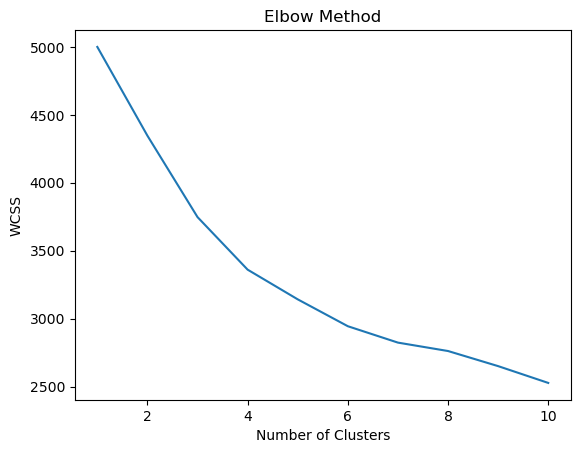

In [21]:
# ================================
# 6. ELBOW METHOD
# ================================
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [22]:
# ================================
# 7. K-MEANS CLUSTERING
# ================================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters

print("\nCluster Distribution:")
print(df['Cluster'].value_counts())



Cluster Distribution:
Cluster
0    313
1    134
2     53
Name: count, dtype: int64


C:\Users\Sagar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [23]:
# ================================
# 8. CLUSTER ANALYSIS
# ================================
cluster_summary = df.groupby('Cluster').mean()
print("\nCluster Summary:")
print(cluster_summary)


Cluster Summary:
            Tenure  MonthlyCharges  TotalCharges  PaperlessBilling  \
Cluster                                                              
0        41.623003      111.888179   4079.894569          0.472843   
1        36.716418      111.335821   4595.888060          0.507463   
2         6.000000      129.773585   4265.754717          0.509434   

         SeniorCitizen  Churn  Contract_One year  Contract_Two year  \
Cluster                                                               
0             0.488818    0.0           0.568690           0.000000   
1             0.529851    0.0           0.000000           1.000000   
2             0.471698    1.0           0.150943           0.188679   

         PaymentMethod_Credit Card  PaymentMethod_Electronic Check  
Cluster                                                             
0                         0.335463                        0.322684  
1                         0.365672                        0.328358  

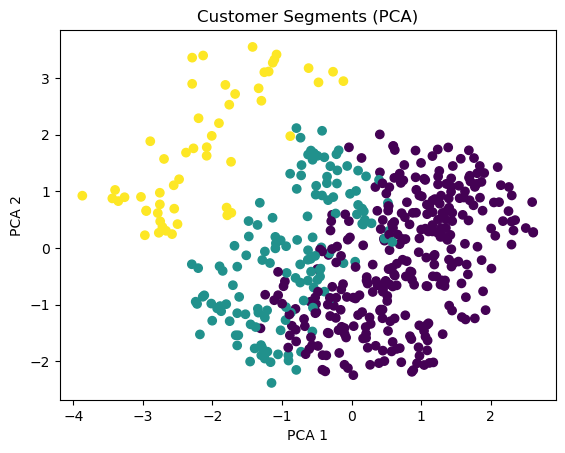

In [24]:
# ================================
# 9. PCA VISUALIZATION
# ================================
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df['Cluster'])
plt.title("Customer Segments (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


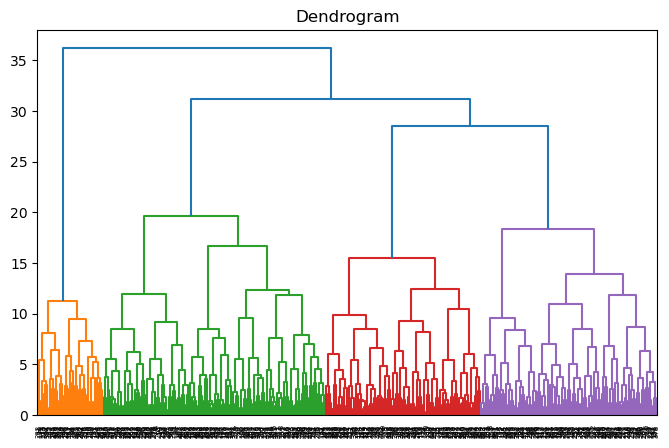

In [25]:
# ================================
# 10. HIERARCHICAL CLUSTERING
# ================================
linked = linkage(scaled_data, method='ward')

plt.figure(figsize=(8,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

In [26]:
# ================================
# 11. DBSCAN
# ================================
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_data)

print("\nDBSCAN Clusters:")
print(df['DBSCAN_Cluster'].value_counts())


DBSCAN Clusters:
DBSCAN_Cluster
-1     245
 1      20
 2      17
 21     17
 13     16
 9      15
 10     14
 4      11
 6      11
 3      10
 8       9
 5       8
 15      8
 14      8
 22      8
 17      7
 25      7
 26      7
 12      7
 20      7
 7       7
 16      6
 18      6
 11      5
 0       5
 19      5
 27      5
 23      5
 24      4
Name: count, dtype: int64


In [27]:
# ================================
# 12. SAVE OUTPUT
# ================================
df.to_csv("segmented_output.csv", index=False)

print("\n✅ Pipeline completed successfully!")


✅ Pipeline completed successfully!


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for segment in df['Cluster'].unique():
    
    segment_df = df[df['Cluster'] == segment]
    
    # Skip small clusters
    if len(segment_df) < 20:
        continue
    
    X = segment_df.drop(['Cluster'], axis=1)
    y = segment_df['Cluster']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    results.append({
        "Segment": segment,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    })

results_df = pd.DataFrame(results)

# Save CSV
results_df.to_csv("model_evaluation_results.csv", index=False)

print(results_df)

   Segment  Accuracy  Precision  Recall  F1 Score
0        0       1.0        1.0     1.0       1.0
1        1       1.0        1.0     1.0       1.0
2        2       1.0        1.0     1.0       1.0
